In [54]:
import kagglehub

path = kagglehub.dataset_download("oscarbatiz/los-angeles-airbnb-listings")
print("Path to dataset files:", path)



Using Colab cache for faster access to the 'los-angeles-airbnb-listings' dataset.
Path to dataset files: /kaggle/input/los-angeles-airbnb-listings


In [55]:
import pandas as pd
import os

file_path = os.path.join(path, "listings.csv")
df_raw = pd.read_csv(file_path, encoding="latin1", low_memory=False)
df = df_raw.copy()

#for col in df.select_dtypes(include="object").columns:
#    df[col] = df[col].map(
#        lambda x: ftfy.fix_text(x) if isinstance(x, str) else x
#    )

In [56]:

df.head()
df.tail()
df.sample(8)

,id,name,host_id,host_name,host_since,host_response_time,host_response_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,...,bathrooms,bedrooms,beds,price,minimum_nights,availability_365,number_of_reviews,review_scores_rating,license,instant_bookable
14345,45057972,Boho Chic Malibu Retreat Estate Pool Views + Yoga,4510075,Michele,27/12/12,within an hour,1.0,NaN,Unincorporated Santa Monica Mountains,Unincorporated Areas,...,3.0,4.0,8.0,1017.0,1,323,18,5.0,NaN,f
15103,41432923,-Prime Location * 1 bed 1 bath,134267499,StayCozy,42895,within an hour,1.0,f,Hollywood,City of Los Angeles,...,1.0,1.0,1.0,96.0,31,62,4,3.5,NaN,f
34570,1139127422754674532,Charming Home by Culver City,15002821,Allison,41761,within an hour,1.0,f,West Adams,City of Los Angeles,...,1.0,2.0,2.0,172.0,3,323,2,5.0,HSR24-001836,f
37874,43770065,Charming Palms Studio Apartment,5994344,Jay,41383,within an hour,1.0,t,Palms,City of Los Angeles,...,NaN,NaN,NaN,NaN,30,178,7,5.0,NaN,f
8889,54370704,LUX NOHO HOME,274353489,Neetha,07/07/19,within an hour,1.0,t,North Hollywood,City of Los Angeles,...,2.0,3.0,3.0,135.0,30,332,5,4.2,NaN,f
29015,1222914446024249909,A Lux Gem Away From Home,507560667,Ashley,45013,within an hour,1.0,f,Glendale,Other Cities,...,1.0,2.0,3.0,144.0,1,334,1,5.0,NaN,t
39850,52583126,COZY ROOM in the HEART of SANTA MONICA UCLA,170272076,Elvina,43127,within a few hours,0.8,f,Brentwood,City of Los Angeles,...,1.0,1.0,1.0,61.0,30,365,1,5.0,NaN,t
44671,909586181539426293,Home Away From Home: listing #2:1 bed:1 or 2 g...,493362627,Daniel,44924,within an hour,1.0,f,Westmont,Unincorporated Areas,...,NaN,2.0,NaN,NaN,2,0,4,5.0,NaN,f


In [57]:
print('\n\n-------------------------------')
print(df.info())
describe_df = df.describe()

print('\n\n-------------------------------')
print(df.dtypes)



-------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45533 entries, 0 to 45532
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            45533 non-null  int64  
 1   name                          45532 non-null  object 
 2   host_id                       45533 non-null  int64  
 3   host_name                     45531 non-null  object 
 4   host_since                    45531 non-null  object 
 5   host_response_time            35445 non-null  object 
 6   host_response_rate            35445 non-null  float64
 7   host_is_superhost             44281 non-null  object 
 8   neighbourhood_cleansed        45533 non-null  object 
 9   neighbourhood_group_cleansed  45533 non-null  object 
 10  latitude                      45533 non-null  float64
 11  longitude                     45533 non-null  float64
 12  property_type             

In [58]:
print(df.shape)
print("-----------")
df.info()
print("-----------")
df.columns

(45533, 25)
-----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45533 entries, 0 to 45532
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            45533 non-null  int64  
 1   name                          45532 non-null  object 
 2   host_id                       45533 non-null  int64  
 3   host_name                     45531 non-null  object 
 4   host_since                    45531 non-null  object 
 5   host_response_time            35445 non-null  object 
 6   host_response_rate            35445 non-null  float64
 7   host_is_superhost             44281 non-null  object 
 8   neighbourhood_cleansed        45533 non-null  object 
 9   neighbourhood_group_cleansed  45533 non-null  object 
 10  latitude                      45533 non-null  float64
 11  longitude                     45533 non-null  float64
 12  property_type                 45533 

Index(['id', 'name', 'host_id', 'host_name', 'host_since',
       'host_response_time', 'host_response_rate', 'host_is_superhost',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'price', 'minimum_nights', 'availability_365',
       'number_of_reviews', 'review_scores_rating', 'license',
       'instant_bookable'],
      dtype='object')

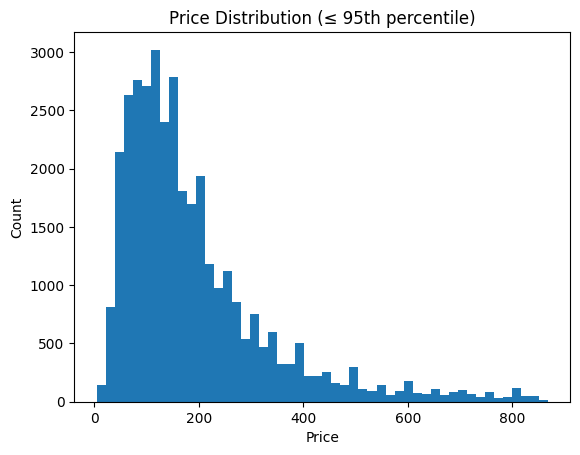

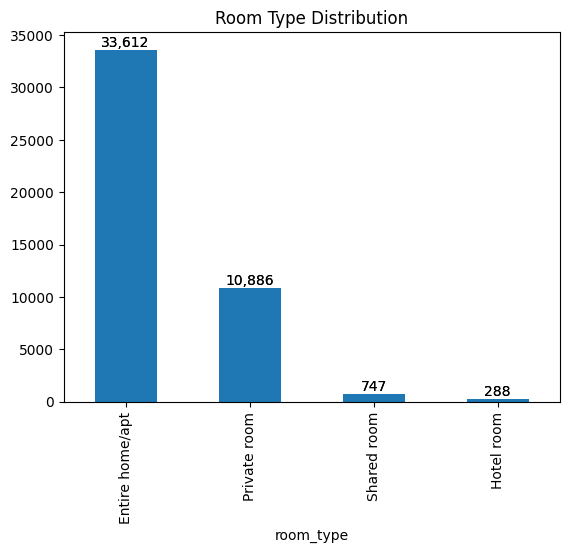

In [59]:
import matplotlib.pyplot as plt

#price vs reservations
price = df["price"].dropna()
upper = price.quantile(0.95)

plt.hist(price[price <= upper], bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution (≤ 95th percentile)")
plt.show()

#types of rooms
ax = df["room_type"].value_counts().plot(kind="bar")
df["room_type"].value_counts().plot(kind="bar")
plt.title("Room Type Distribution")
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.show()


In [60]:
df = df_raw.copy() # Re-initialize df from df_raw to ensure all columns are present
df['missing_flag'] = df.isna().any(axis=1).astype(int)
df['missing_flag'].value_counts()

ratings_mean = df["review_scores_rating"].mean()
df["review_scores_rating"] = df["review_scores_rating"].fillna(ratings_mean)

price_mean = df["price"].mean()
df["price"] = df["price"].fillna(price_mean)


bedrooms_mean = df["bedrooms"].mean()
df["bedrooms"] = df["bedrooms"].fillna(bedrooms_mean)

beds_mean = df["beds"].mean()
df["beds"] = df["beds"].fillna(beds_mean)

bathrooms_mean = df["bathrooms"].mean()
df["bathrooms"] = df["bathrooms"].fillna(bathrooms_mean)

df['review_scores_rating'] = df['review_scores_rating'] / 5
df[['review_scores_rating']].describe()

upper_threshold = df['price'].quantile(0.95)
df = df[df['price'] <= upper_threshold]

# Drop specified columns and update df
df = df.drop(columns=['license', 'host_response_time', 'host_response_rate', 'host_is_superhost', 'host_name', 'host_since', 'host_id', 'id', 'availability_365', 'instant_bookable', 'number_of_reviews', 'neighbourhood_group_cleansed', 'minimum_nights', 'property_type'])
df['city'] = 'Los Angeles'

df.rename(columns={'neighbourhood_cleansed': 'neighbourhood'}, inplace=True)

df.isna().sum().sort_values(ascending=False)

,0
name,1
neighbourhood,0
latitude,0
longitude,0
room_type,0
accommodates,0
bathrooms,0
bedrooms,0
beds,0
price,0


In [61]:
df.to_csv('la_cleaned.csv', index=False)
print('DataFrame successfully exported to la_cleaned.csv')

DataFrame successfully exported to la_cleaned.csv


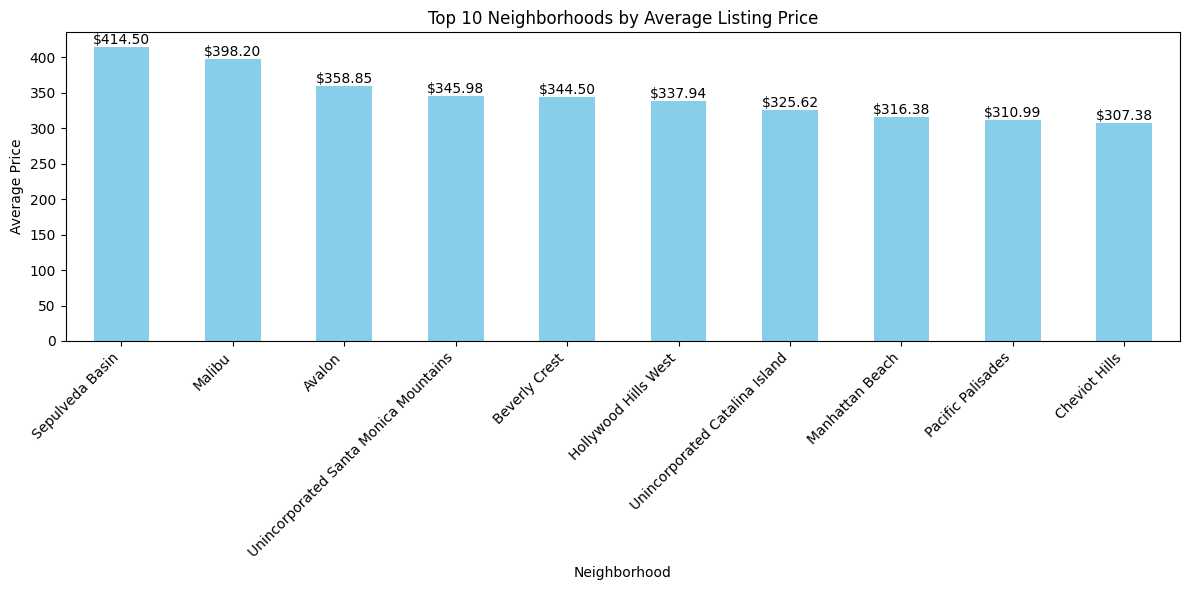

In [62]:
import matplotlib.pyplot as plt

# Calculate the average price for each neighborhood and sort them
top_10_neighborhoods_by_price = df.groupby("neighbourhood")["price"].mean().nlargest(10)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
top_10_neighborhoods_by_price.plot(kind="bar", ax=ax, color='skyblue')

plt.title("Top 10 Neighborhoods by Average Listing Price")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")

# Add value labels on top of the bars
for p in ax.patches:
    ax.annotate(
        f"${p.get_height():,.2f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

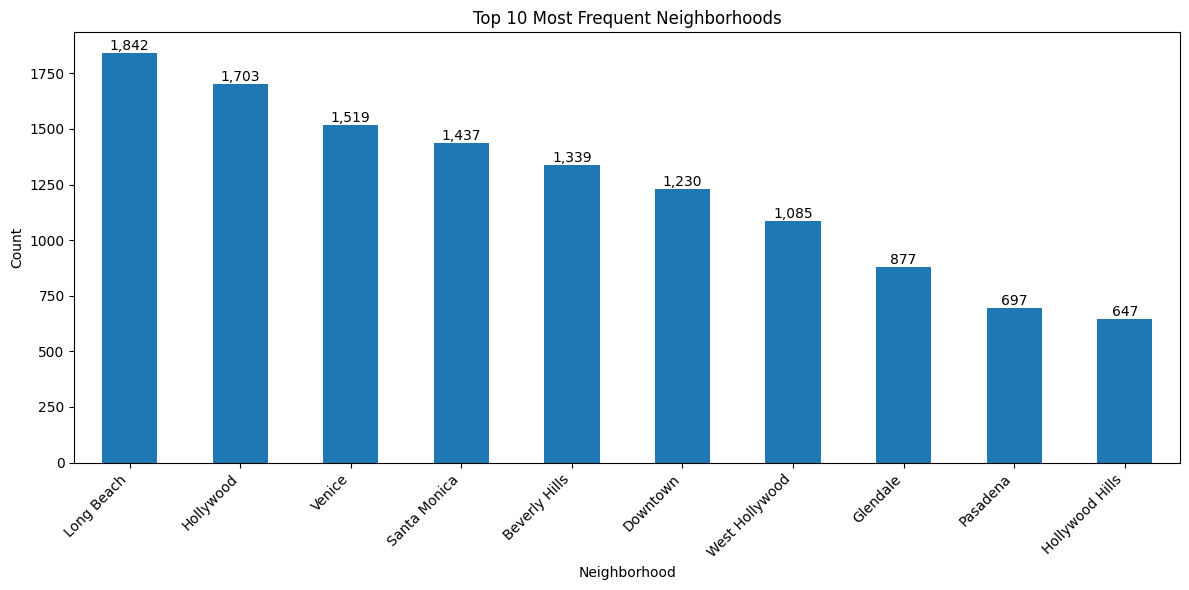

In [63]:
import matplotlib.pyplot as plt

top_10_neighborhoods = df["neighbourhood"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
top_10_neighborhoods.plot(kind="bar", ax=ax)
plt.title("Top 10 Most Frequent Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )
plt.tight_layout()
plt.show()

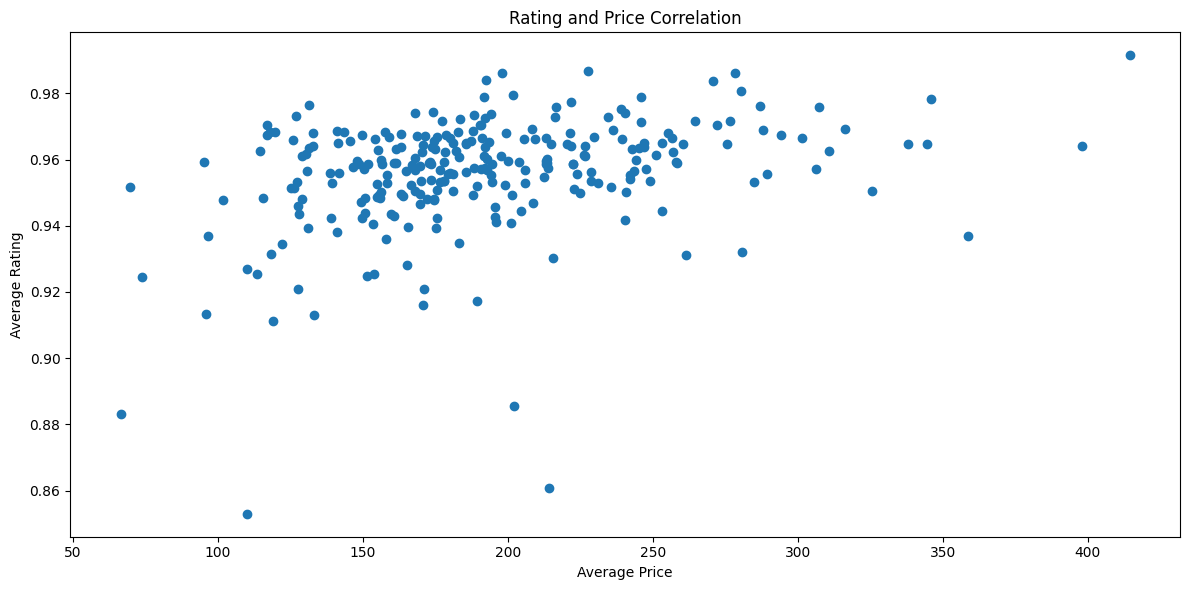

In [64]:
import matplotlib.pyplot as plt

# Calculate average price and average rating per neighborhood
neighborhood_stats = df.groupby("neighbourhood").agg(
    avg_price=("price", "mean"),
    avg_rating=("review_scores_rating", "mean")
).reset_index()

# Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(x=neighborhood_stats["avg_price"], y=neighborhood_stats["avg_rating"])

plt.title("Rating and Price Correlation")
plt.xlabel("Average Price")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [65]:
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols].describe()

,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,review_scores_rating,missing_flag
count,43257.000000,43257.000000,43257.000000,43257.000000,43257.000000,43257.000000,43257.000000,43257.000000,43257.000000
mean,34.054941,-118.306362,3.770396,1.515782,1.665922,2.135914,204.337740,0.955475,0.823890
std,0.142589,0.170913,2.592988,0.816236,1.137794,1.476232,124.845426,0.071421,0.380918
min,33.338360,-118.907660,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000
25%,33.997260,-118.407803,2.000000,1.000000,1.000000,1.000000,105.000000,0.955749,1.000000
50%,34.060150,-118.338910,3.000000,1.000000,1.000000,2.000000,180.000000,0.960000,1.000000
75%,34.107860,-118.219080,5.000000,2.000000,2.000000,2.255786,289.377762,0.996000,1.000000
max,34.811183,-117.653352,16.000000,50.000000,50.000000,50.000000,735.000000,1.000000,1.000000


In [66]:
df["room_type"].value_counts()

,count
room_type,
Entire home/apt,31445
Private room,10824
Shared room,744
Hotel room,244


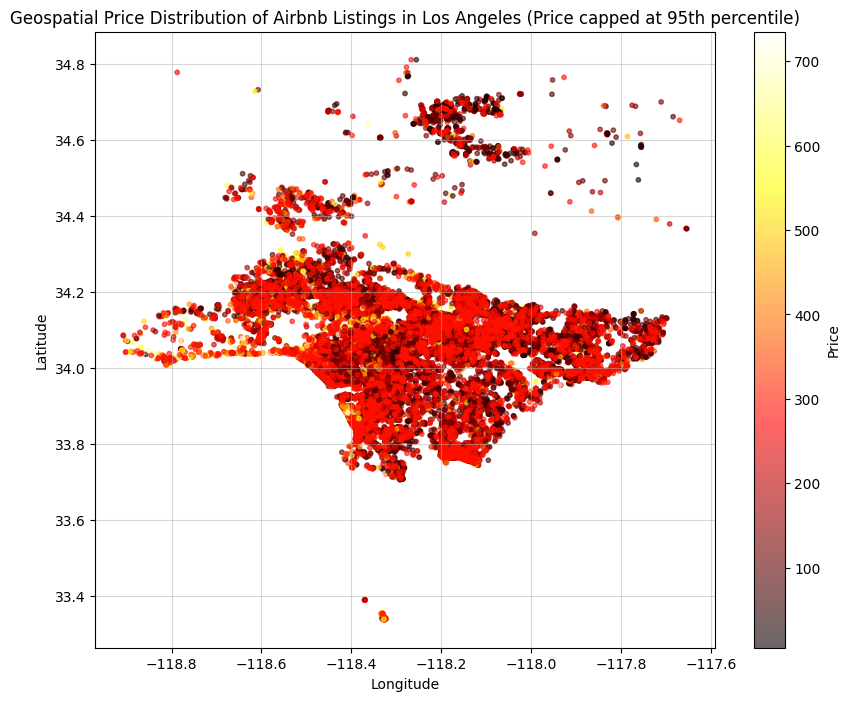

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(x=df['longitude'], y=df['latitude'], c=df['price'].clip(upper=upper), cmap='hot', alpha=0.6, s=10)
plt.colorbar(label='Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geospatial Price Distribution of Airbnb Listings in Los Angeles (Price capped at 95th percentile)')
plt.grid(True, alpha=0.5)
plt.show()

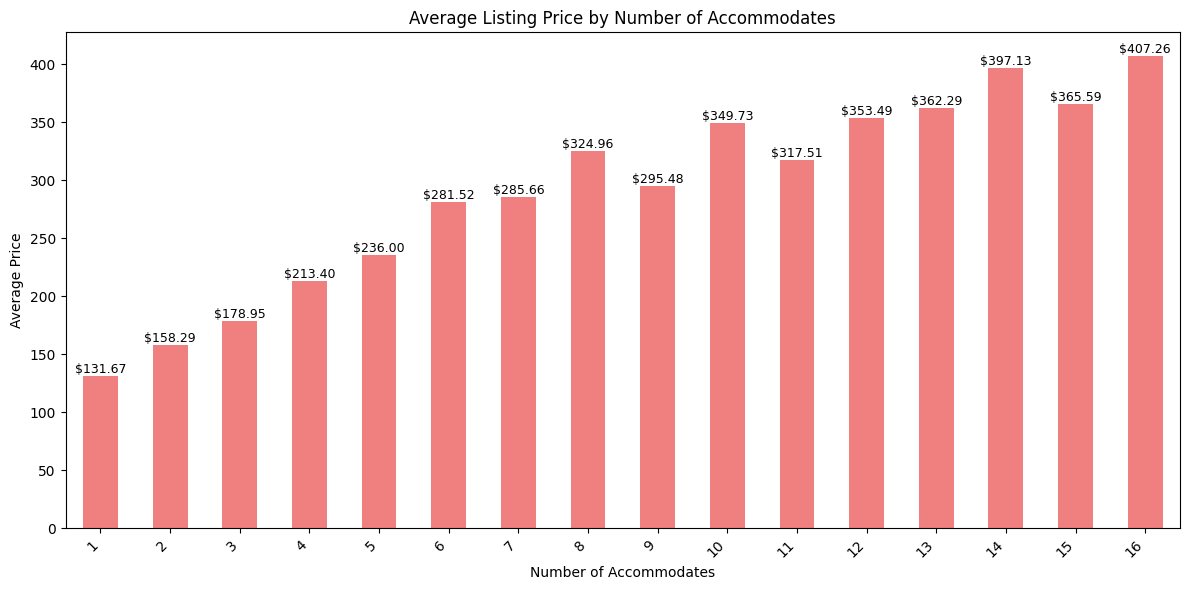

In [68]:
import matplotlib.pyplot as plt

# Calculate the average listing price for each 'accommodates' value
avg_price_by_accommodates = df.groupby('accommodates')['price'].mean()

# Create the bar chart
plt.figure(figsize=(12, 6))
avg_price_by_accommodates.plot(kind='bar', color='lightcoral')

# Add labels and title
plt.xlabel('Number of Accommodates')
plt.ylabel('Average Price')
plt.title('Average Listing Price by Number of Accommodates')

# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=45, ha='right')

# Add value labels on top of the bars
for index, value in enumerate(avg_price_by_accommodates):
    plt.text(index, value, f'${value:,.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [69]:
la = pd.read_csv("la_cleaned.csv")
la.sample(6)

,name,neighbourhood,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,review_scores_rating,missing_flag,city
36827,èå¸æ¶ä»£å¹¿åºé«çº§å ¬å¯äºæ¿äºå«æµ´,Alhambra,34.070040,-118.134350,Entire home/apt,4,1.649434,2.0,2.255786,289.377762,0.955749,1,Los Angeles
7841,Private gated house with amazing patio in Weho,West Hollywood,34.092940,-118.383230,Entire home/apt,3,1.000000,1.0,1.000000,200.000000,0.866000,1,Los Angeles
7184,Bright 2-BR Home with Free Parking in Center-City,West Adams,34.032081,-118.364109,Entire home/apt,5,1.000000,2.0,3.000000,100.000000,1.000000,0,Los Angeles
3003,Beautiful room in Redondo /Hermosa,Redondo Beach,33.872810,-118.373860,Private room,1,1.000000,1.0,1.000000,99.000000,0.956000,1,Los Angeles
576,Lux Heated Pool&Spa Getaway near Disney,Long Beach,33.824122,-118.099282,Entire home/apt,8,2.000000,3.0,3.000000,255.000000,1.000000,0,Los Angeles
38774,Artisan House w/ Sauna & Trees!,Echo Park,34.087810,-118.253710,Entire home/apt,3,1.649434,2.0,2.255786,289.377762,1.000000,1,Los Angeles


In [70]:
from google.colab import files
files.download("la_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>